In [1]:
!pip install lightgbm scikit-learn pandas numpy alpaca-py python-dotenv

In [6]:
"""
ML Signal Generation Pipeline
Predicts intraday returns and volatility using ensemble methods.
Designed to consume output from DataCleaner in data_download.py.
"""

import pandas as pd
import numpy as np
from typing import Optional, Tuple, Dict, List
from dataclasses import dataclass, field
import warnings
import json

warnings.filterwarnings("ignore")

# ── ML imports ──────────────────────────────────────────────────────────────
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb


# ═══════════════════════════════════════════════════════════════════════════════
# 1. PURGED CROSS-VALIDATION
# ═══════════════════════════════════════════════════════════════════════════════

class PurgedTimeSeriesSplit:
    """
    Time-series cross-validation with purging and embargo.

    Purging removes samples from the training set that overlap with the
    test set's label horizon, preventing lookahead bias from rolling
    window features and forward-looking targets.

    Embargo adds a gap after the purge zone for extra safety.
    """

    def __init__(
        self,
        n_splits: int = 5,
        purge_window: int = 20,
        embargo_window: int = 5
    ):
        """
        Args:
            n_splits: Number of CV folds
            purge_window: Bars to purge before test set (match your max feature lookback)
            embargo_window: Additional gap bars after purge zone
        """
        self.n_splits = n_splits
        self.purge_window = purge_window
        self.embargo_window = embargo_window

    def split(self, X: pd.DataFrame):
        """
        Yield (train_indices, test_indices) with purging + embargo applied.
        """
        n_samples = len(X)
        test_size = n_samples // (self.n_splits + 1)

        for i in range(self.n_splits):
            test_start = (i + 1) * test_size
            test_end = test_start + test_size

            if test_end > n_samples:
                test_end = n_samples

            # Training set: everything before test, minus purge+embargo zone
            train_end = max(0, test_start - self.purge_window - self.embargo_window)
            train_indices = np.arange(0, train_end)
            test_indices = np.arange(test_start, test_end)

            if len(train_indices) > 0 and len(test_indices) > 0:
                yield train_indices, test_indices


# ═══════════════════════════════════════════════════════════════════════════════
# 2. TARGET CONSTRUCTION
# ═══════════════════════════════════════════════════════════════════════════════

class TargetBuilder:
    """
    Constructs forward-looking targets for return and volatility prediction.
    """

    @staticmethod
    def build_return_target(
        df: pd.DataFrame,
        horizon: int = 10,
        clip_std: float = 3.0
    ) -> pd.Series:
        """
        Forward return over `horizon` bars, winsorized at `clip_std` stdevs.

        Args:
            df: DataFrame with 'Close' column
            horizon: Number of bars to look ahead
            clip_std: Winsorize at +/- this many standard deviations

        Returns:
            Series of forward returns (NaN at the end where target unavailable)
        """
        fwd_return = df["Close"].pct_change(periods=horizon).shift(-horizon)

        # Winsorize to reduce impact of outliers
        mu = fwd_return.mean()
        sigma = fwd_return.std()
        lower = mu - clip_std * sigma
        upper = mu + clip_std * sigma
        fwd_return = fwd_return.clip(lower=lower, upper=upper)

        return fwd_return.rename(f"fwd_return_{horizon}")

    @staticmethod
    def build_volatility_target(
        df: pd.DataFrame,
        horizon: int = 20,
        annualize: bool = False,
        bars_per_day: int = 390
    ) -> pd.Series:
        """
        Forward realized volatility over `horizon` bars.

        Uses log returns for better statistical properties.

        Args:
            df: DataFrame with 'Close' column
            horizon: Window size for realized vol calculation
            annualize: Whether to annualize the volatility
            bars_per_day: Bars per trading day (390 for 1-min equities)

        Returns:
            Series of forward realized volatility
        """
        log_returns = np.log(df["Close"] / df["Close"].shift(1))

        # Forward-looking realized vol: std of next `horizon` log returns
        fwd_vol = log_returns.shift(-horizon).rolling(window=horizon).std()
        # Shift again so each row maps to vol starting from the next bar
        fwd_vol = fwd_vol.shift(-horizon + horizon)  # simplifies to no extra shift

        # More precise: use a custom forward-looking window
        fwd_vol_values = pd.Series(index=df.index, dtype=float)
        log_ret_arr = log_returns.values
        n = len(log_ret_arr)
        for i in range(n - horizon):
            window = log_ret_arr[i + 1: i + 1 + horizon]
            valid = window[~np.isnan(window)]
            if len(valid) >= horizon // 2:
                fwd_vol_values.iloc[i] = np.std(valid, ddof=1)

        if annualize:
            fwd_vol_values *= np.sqrt(bars_per_day * 252)

        return fwd_vol_values.rename(f"fwd_vol_{horizon}")


# ═══════════════════════════════════════════════════════════════════════════════
# 3. FEATURE ENGINEERING & SELECTION
# ═══════════════════════════════════════════════════════════════════════════════

class FeatureEngineer:
    """
    Additional feature engineering on top of DataCleaner output,
    plus feature selection utilities.
    """

    # Columns from DataCleaner that are raw OHLCV, not features
    RAW_COLS = {"Open", "High", "Low", "Close", "Volume"}

    @staticmethod
    def add_microstructure_features(df: pd.DataFrame) -> pd.DataFrame:
        """
        Add microstructure-inspired features useful for intraday prediction.
        """
        out = df.copy()

        # ── Realized variance components ─────────────────────────────
        log_ret = np.log(out["Close"] / out["Close"].shift(1))

        # Signed realized variance (up vs down vol asymmetry)
        for w in [10, 30, 60]:
            pos_var = (log_ret.clip(lower=0) ** 2).rolling(w).sum()
            neg_var = (log_ret.clip(upper=0) ** 2).rolling(w).sum()
            out[f"RV_Ratio_{w}"] = pos_var / (pos_var + neg_var + 1e-12)

        # ── Garman-Klass volatility estimator ────────────────────────
        for w in [10, 30]:
            gk = (
                0.5 * (np.log(out["High"] / out["Low"])) ** 2
                - (2 * np.log(2) - 1) * (np.log(out["Close"] / out["Open"])) ** 2
            )
            out[f"GK_Vol_{w}"] = gk.rolling(w).mean().apply(
                lambda x: np.sqrt(max(x, 0))
            )

        # ── Order flow proxy (volume-weighted returns) ───────────────
        for w in [10, 30]:
            signed_vol = log_ret * out["Volume"]
            out[f"OFI_{w}"] = signed_vol.rolling(w).sum()

        # ── Amihud illiquidity ───────────────────────────────────────
        for w in [10, 30]:
            illiq = log_ret.abs() / (out["Volume"] * out["Close"] + 1e-12)
            out[f"Amihud_{w}"] = illiq.rolling(w).mean()

        # ── Momentum features (rate of change) ───────────────────────
        for w in [5, 10, 30, 60]:
            out[f"ROC_{w}"] = out["Close"].pct_change(w)

        # ── Mean reversion z-score ───────────────────────────────────
        for w in [20, 60]:
            ma = out["Close"].rolling(w).mean()
            std = out["Close"].rolling(w).std()
            out[f"ZScore_{w}"] = (out["Close"] - ma) / (std + 1e-12)

        return out

    @staticmethod
    def select_features(
        df: pd.DataFrame,
        target: pd.Series,
        method: str = "importance",
        top_k: int = 30,
        lgb_params: Optional[dict] = None
    ) -> List[str]:
        """
        Select top features using LightGBM feature importance.

        Args:
            df: Feature DataFrame
            target: Target Series
            method: Selection method ('importance' supported)
            top_k: Number of features to keep
            lgb_params: Optional LightGBM parameters

        Returns:
            List of selected feature names
        """
        # Align and drop NaN
        common_idx = df.index.intersection(target.dropna().index)
        X = df.loc[common_idx]
        y = target.loc[common_idx]
        mask = ~(X.isna().any(axis=1) | y.isna())
        X, y = X[mask], y[mask]

        if lgb_params is None:
            lgb_params = {
                "objective": "regression",
                "n_estimators": 200,
                "max_depth": 4,
                "learning_rate": 0.05,
                "subsample": 0.7,
                "colsample_bytree": 0.7,
                "verbose": -1,
                "n_jobs": -1,
            }

        model = lgb.LGBMRegressor(**lgb_params)
        model.fit(X, y)

        importances = pd.Series(
            model.feature_importances_, index=X.columns
        ).sort_values(ascending=False)

        selected = importances.head(top_k).index.tolist()
        print(f"Selected {len(selected)} features by importance.")
        return selected

    @classmethod
    def get_feature_columns(cls, df: pd.DataFrame) -> List[str]:
        """Return all non-raw columns as feature candidates."""
        return [c for c in df.columns if c not in cls.RAW_COLS]


# ═══════════════════════════════════════════════════════════════════════════════
# 4. MODEL WRAPPERS
# ═══════════════════════════════════════════════════════════════════════════════

@dataclass
class ModelResult:
    """Container for model evaluation results."""
    model_name: str
    target_name: str
    metrics: Dict[str, float]
    feature_importance: Optional[pd.Series] = None
    predictions: Optional[pd.Series] = None
    fold_metrics: List[Dict[str, float]] = field(default_factory=list)


class LightGBMModel:
    """LightGBM wrapper for return/vol prediction."""

    def __init__(self, params: Optional[dict] = None, task: str = "return"):
        """
        Args:
            params: LightGBM parameters (sensible defaults provided)
            task: 'return' or 'volatility' (adjusts defaults)
        """
        self.task = task

        if params is None:
            self.params = {
                "objective": "regression",
                "metric": "mse",
                "n_estimators": 500,
                "max_depth": 5,
                "num_leaves": 31,
                "learning_rate": 0.03,
                "subsample": 0.7,
                "colsample_bytree": 0.6,
                "reg_alpha": 0.1,
                "reg_lambda": 1.0,
                "min_child_samples": 50,
                "verbose": -1,
                "n_jobs": -1,
            }
            if task == "volatility":
                # Vol is smoother → can use slightly deeper trees
                self.params["max_depth"] = 6
                self.params["min_child_samples"] = 30
                self.params["learning_rate"] = 0.05
        else:
            self.params = params

        self.model = None
        self.feature_names = None

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series):
        """Fit the model."""
        self.feature_names = X_train.columns.tolist()
        self.model = lgb.LGBMRegressor(**self.params)
        self.model.fit(
            X_train, y_train,
            callbacks=[lgb.log_evaluation(period=0)],
        )
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """Generate predictions."""
        return self.model.predict(X)

    def get_feature_importance(self) -> pd.Series:
        """Return feature importances sorted descending."""
        return pd.Series(
            self.model.feature_importances_,
            index=self.feature_names
        ).sort_values(ascending=False)


class ElasticNetModel:
    """Elastic Net wrapper with built-in scaling and optional CV alpha tuning."""

    def __init__(self, alpha: float = 0.001, l1_ratio: float = 0.5, auto_tune: bool = True):
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.auto_tune = auto_tune
        self.scaler = StandardScaler()
        self.target_scaler = StandardScaler()
        self.model = None
        self.feature_names = None

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series):
        self.feature_names = X_train.columns.tolist()
        X_scaled = self.scaler.fit_transform(X_train)
        # Scale target too — vol targets are ~1e-4 which makes alpha relatively huge
        y_scaled = self.target_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()

        if self.auto_tune:
            self.model = ElasticNetCV(
                l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
                alphas=np.logspace(-6, -1, 30),
                cv=TimeSeriesSplit(n_splits=3),
                max_iter=10000,
                random_state=42,
            )
        else:
            self.model = ElasticNet(
                alpha=self.alpha,
                l1_ratio=self.l1_ratio,
                max_iter=10000,
                random_state=42,
            )
        self.model.fit(X_scaled, y_scaled)
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        X_scaled = self.scaler.transform(X)
        y_scaled = self.model.predict(X_scaled)
        return self.target_scaler.inverse_transform(y_scaled.reshape(-1, 1)).ravel()

    def get_feature_importance(self) -> pd.Series:
        return pd.Series(
            np.abs(self.model.coef_),
            index=self.feature_names
        ).sort_values(ascending=False)


# ═══════════════════════════════════════════════════════════════════════════════
# 5. ENSEMBLE & SIGNAL GENERATOR
# ═══════════════════════════════════════════════════════════════════════════════

class EnsembleSignalGenerator:
    """
    Combines return and volatility predictions into trading signals.

    Signal = alpha_forecast / vol_forecast  (vol-adjusted expected return)
    This naturally produces a risk-adjusted signal: positions are larger
    when expected return is high AND vol is low.
    """

    def __init__(
        self,
        return_models: Optional[List] = None,
        vol_models: Optional[List] = None,
        return_weights: Optional[List[float]] = None,
        vol_weights: Optional[List[float]] = None,
    ):
        self.return_models = return_models or []
        self.vol_models = vol_models or []
        self.return_weights = return_weights
        self.vol_weights = vol_weights

    def _weighted_avg(
        self, predictions: List[np.ndarray], weights: Optional[List[float]]
    ) -> np.ndarray:
        """Weighted average of model predictions."""
        if weights is None:
            weights = [1.0 / len(predictions)] * len(predictions)
        weights = np.array(weights) / np.sum(weights)
        return sum(w * p for w, p in zip(weights, predictions))

    def generate_signals(
        self,
        X: pd.DataFrame,
        index: pd.Index,
        signal_type: str = "vol_adjusted"
    ) -> pd.DataFrame:
        """
        Generate trading signals from ensemble predictions.

        Args:
            X: Feature DataFrame
            index: DatetimeIndex for the output
            signal_type: 'vol_adjusted' (default), 'raw_return', or 'rank'

        Returns:
            DataFrame with columns: return_forecast, vol_forecast, signal, signal_z
        """
        # Return predictions
        ret_preds = [m.predict(X) for m in self.return_models]
        ret_ensemble = self._weighted_avg(ret_preds, self.return_weights)

        # Volatility predictions
        vol_preds = [m.predict(X) for m in self.vol_models]
        vol_ensemble = self._weighted_avg(vol_preds, self.vol_weights)

        # Ensure vol > 0
        vol_ensemble = np.maximum(vol_ensemble, 1e-8)

        signals = pd.DataFrame(index=index)
        signals["return_forecast"] = ret_ensemble
        signals["vol_forecast"] = vol_ensemble

        if signal_type == "vol_adjusted":
            signals["signal"] = signals["return_forecast"] / signals["vol_forecast"]
        elif signal_type == "raw_return":
            signals["signal"] = signals["return_forecast"]
        elif signal_type == "rank":
            signals["signal"] = signals["return_forecast"].rank(pct=True) - 0.5

        # Z-score the signal for consistent scaling
        sig_mean = signals["signal"].rolling(200, min_periods=50).mean()
        sig_std = signals["signal"].rolling(200, min_periods=50).std()
        signals["signal_z"] = (signals["signal"] - sig_mean) / (sig_std + 1e-12)

        return signals


# ═══════════════════════════════════════════════════════════════════════════════
# 6. EVALUATION ENGINE
# ═══════════════════════════════════════════════════════════════════════════════

class ModelEvaluator:
    """
    Evaluates models using purged cross-validation and computes
    relevant metrics for trading signal quality.
    """

    @staticmethod
    def evaluate_model(
        model,
        X: pd.DataFrame,
        y: pd.Series,
        cv: PurgedTimeSeriesSplit,
        model_name: str = "Model",
        target_name: str = "target"
    ) -> ModelResult:
        """
        Run purged CV evaluation on a single model.

        Returns:
            ModelResult with per-fold and aggregate metrics
        """
        fold_metrics = []
        all_preds = pd.Series(dtype=float, index=X.index)

        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X)):
            X_train = X.iloc[train_idx]
            y_train = y.iloc[train_idx]
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]

            # Clone model for each fold
            import copy
            fold_model = copy.deepcopy(model)
            fold_model.fit(X_train, y_train)
            preds = fold_model.predict(X_test)

            # Compute metrics
            mse = mean_squared_error(y_test, preds)
            mae = mean_absolute_error(y_test, preds)
            r2 = r2_score(y_test, preds)

            # Directional accuracy (for returns)
            if "return" in target_name.lower():
                dir_acc = np.mean(np.sign(preds) == np.sign(y_test.values))
            else:
                dir_acc = np.nan

            # IC (information coefficient = rank correlation)
            ic = pd.Series(preds, index=y_test.index).corr(y_test, method="spearman")

            fold_metrics.append({
                "fold": fold_idx,
                "mse": mse,
                "rmse": np.sqrt(mse),
                "mae": mae,
                "r2": r2,
                "ic": ic,
                "directional_accuracy": dir_acc,
            })

            all_preds.iloc[test_idx] = preds

        # Aggregate metrics
        metrics_df = pd.DataFrame(fold_metrics)
        agg_metrics = {
            "mean_rmse": metrics_df["rmse"].mean(),
            "std_rmse": metrics_df["rmse"].std(),
            "mean_r2": metrics_df["r2"].mean(),
            "mean_ic": metrics_df["ic"].mean(),
            "ic_ir": metrics_df["ic"].mean() / (metrics_df["ic"].std() + 1e-12),
            "mean_directional_accuracy": metrics_df["directional_accuracy"].mean(),
        }

        # Fit on full data for feature importance
        import copy
        full_model = copy.deepcopy(model)
        full_model.fit(X, y)
        feat_imp = full_model.get_feature_importance()

        return ModelResult(
            model_name=model_name,
            target_name=target_name,
            metrics=agg_metrics,
            feature_importance=feat_imp,
            predictions=all_preds,
            fold_metrics=fold_metrics,
        )

    @staticmethod
    def print_results(result: ModelResult):
        """Pretty-print evaluation results."""
        print(f"\n{'='*60}")
        print(f"  {result.model_name} → {result.target_name}")
        print(f"{'='*60}")
        m = result.metrics
        print(f"  RMSE:      {m['mean_rmse']:.6f} ± {m['std_rmse']:.6f}")
        print(f"  R²:        {m['mean_r2']:.4f}")
        print(f"  IC (mean): {m['mean_ic']:.4f}")
        print(f"  ICIR:      {m['ic_ir']:.4f}")
        if not np.isnan(m["mean_directional_accuracy"]):
            print(f"  Dir Acc:   {m['mean_directional_accuracy']:.2%}")

        if result.feature_importance is not None:
            print(f"\n  Top 10 Features:")
            for feat, imp in result.feature_importance.head(10).items():
                print(f"    {feat:30s}  {imp:.4f}")


# ═══════════════════════════════════════════════════════════════════════════════
# 7. MAIN PIPELINE
# ═══════════════════════════════════════════════════════════════════════════════

def run_pipeline(
    df_cleaned: pd.DataFrame,
    return_horizon: int = 10,
    vol_horizon: int = 20,
    n_cv_splits: int = 5,
    purge_window: int = 30,
    embargo_window: int = 10,
    top_k_features: int = 30,
    signal_type: str = "vol_adjusted",
) -> Tuple[pd.DataFrame, Dict[str, ModelResult]]:
    """
    End-to-end pipeline: features → targets → train → evaluate → signals.

    Args:
        df_cleaned: Output from DataCleaner.prepare_data()
        return_horizon: Forward return horizon in bars
        vol_horizon: Forward volatility horizon in bars
        n_cv_splits: Number of cross-validation folds
        purge_window: Bars to purge between train/test
        embargo_window: Additional embargo gap
        top_k_features: Number of features to select
        signal_type: Signal construction method

    Returns:
        (signals_df, results_dict) — signals DataFrame and model results
    """
    print("=" * 70)
    print("  ML SIGNAL GENERATION PIPELINE")
    print("=" * 70)

    # ── Step 1: Add microstructure features ──────────────────────────
    print("\n[1/6] Adding microstructure features...")
    fe = FeatureEngineer()
    df_feat = fe.add_microstructure_features(df_cleaned)

    # ── Step 2: Build targets ────────────────────────────────────────
    print("[2/6] Building targets...")
    tb = TargetBuilder()
    ret_target = tb.build_return_target(df_feat, horizon=return_horizon)
    vol_target = tb.build_volatility_target(df_feat, horizon=vol_horizon)

    # ── Step 3: Align features + targets, drop NaN ───────────────────
    print("[3/6] Aligning data and selecting features...")
    feature_cols = fe.get_feature_columns(df_feat)
    X_all = df_feat[feature_cols].copy()

    # Combine everything to drop NaN rows consistently
    combined = pd.concat([X_all, ret_target, vol_target], axis=1).dropna()
    X = combined[feature_cols]
    y_ret = combined[ret_target.name]
    y_vol = combined[vol_target.name]

    print(f"    Dataset: {X.shape[0]} samples, {X.shape[1]} raw features")

    # Feature selection
    selected_ret = fe.select_features(X, y_ret, top_k=top_k_features)
    selected_vol = fe.select_features(X, y_vol, top_k=top_k_features)
    # Union of selected features
    selected_all = list(set(selected_ret + selected_vol))
    X = X[selected_all]
    print(f"    Using {len(selected_all)} features after selection")

    # ── Step 4: Train & evaluate models ──────────────────────────────
    print("[4/6] Training and evaluating models...")
    cv = PurgedTimeSeriesSplit(
        n_splits=n_cv_splits,
        purge_window=purge_window,
        embargo_window=embargo_window,
    )
    evaluator = ModelEvaluator()
    results = {}

    # --- Return models ---
    lgb_ret = LightGBMModel(task="return")
    enet_ret = ElasticNetModel(alpha=0.001, l1_ratio=0.5)

    print("\n  ── Return Prediction ──")
    r1 = evaluator.evaluate_model(lgb_ret, X, y_ret, cv, "LightGBM", "return")
    evaluator.print_results(r1)
    results["lgb_return"] = r1

    r2 = evaluator.evaluate_model(enet_ret, X, y_ret, cv, "ElasticNet", "return")
    evaluator.print_results(r2)
    results["enet_return"] = r2

    # --- Volatility models ---
    lgb_vol = LightGBMModel(task="volatility")
    enet_vol = ElasticNetModel(alpha=0.001, l1_ratio=0.3)

    print("\n  ── Volatility Prediction ──")
    r3 = evaluator.evaluate_model(lgb_vol, X, y_vol, cv, "LightGBM", "volatility")
    evaluator.print_results(r3)
    results["lgb_vol"] = r3

    r4 = evaluator.evaluate_model(enet_vol, X, y_vol, cv, "ElasticNet", "volatility")
    evaluator.print_results(r4)
    results["enet_vol"] = r4

    # ── Step 5: Fit final models on full data ────────────────────────
    print("\n[5/6] Fitting final models on full dataset...")
    lgb_ret_final = LightGBMModel(task="return")
    lgb_ret_final.fit(X, y_ret)

    enet_ret_final = ElasticNetModel(alpha=0.001, l1_ratio=0.5)
    enet_ret_final.fit(X, y_ret)

    lgb_vol_final = LightGBMModel(task="volatility")
    lgb_vol_final.fit(X, y_vol)

    enet_vol_final = ElasticNetModel(alpha=0.001, l1_ratio=0.3)
    enet_vol_final.fit(X, y_vol)

    # ── Step 6: Generate signals ─────────────────────────────────────
    print("[6/6] Generating trading signals...")

    # Weight models by IC (better IC → more weight), fallback to equal weights
    ret_ics = [abs(results["lgb_return"].metrics["mean_ic"]),
               abs(results["enet_return"].metrics["mean_ic"])]
    vol_ics = [abs(results["lgb_vol"].metrics["mean_ic"]),
               abs(results["enet_vol"].metrics["mean_ic"])]

    # Replace NaN weights with 0, fallback to equal if all NaN
    ret_ics = [0.0 if np.isnan(w) else w for w in ret_ics]
    vol_ics = [0.0 if np.isnan(w) else w for w in vol_ics]
    if sum(ret_ics) == 0:
        ret_ics = [1.0, 1.0]
    if sum(vol_ics) == 0:
        vol_ics = [1.0, 1.0]

    generator = EnsembleSignalGenerator(
        return_models=[lgb_ret_final, enet_ret_final],
        vol_models=[lgb_vol_final, enet_vol_final],
        return_weights=ret_ics,
        vol_weights=vol_ics,
    )

    signals = generator.generate_signals(X, index=X.index, signal_type=signal_type)

    # Add actual values for comparison
    signals["actual_return"] = y_ret
    signals["actual_vol"] = y_vol

    # Summary stats
    print(f"\n{'='*70}")
    print("  SIGNAL SUMMARY")
    print(f"{'='*70}")
    sz = signals["signal_z"].dropna()
    print(f"  Valid signals: {len(sz)} / {len(signals)}")
    print(f"  Signal mean:    {sz.mean():.4f}")
    print(f"  Signal std:     {sz.std():.4f}")
    print(f"  Signal skew:    {sz.skew():.4f}")
    print(f"  Signal kurt:    {sz.kurtosis():.4f}")

    # Signal-return correlation (key metric)
    valid = signals[["signal_z", "actual_return"]].dropna()
    sig_ret_corr = valid["signal_z"].corr(valid["actual_return"])
    print(f"  Signal-Return corr: {sig_ret_corr:.4f}")

    # Quintile analysis
    valid_signals = signals["signal_z"].dropna()
    if len(valid_signals) > 10:
        signals["quintile"] = pd.qcut(
            signals["signal_z"], q=5, labels=False, duplicates="drop"
        )
        quintile_rets = signals.dropna(subset=["quintile"]).groupby("quintile")["actual_return"].mean()
        print(f"\n  Quintile Returns (annualized proxy):")
        for q, r in quintile_rets.items():
            print(f"    Q{int(q)}: {r:.6f}")
        if len(quintile_rets) >= 2:
            spread = quintile_rets.iloc[-1] - quintile_rets.iloc[0]
            print(f"    Long-Short Spread: {spread:.6f}")
        else:
            print("    (Not enough quintiles for spread calculation)")
    else:
        print("\n  Quintile analysis skipped — insufficient valid signals.")
        signals["quintile"] = np.nan

    return signals, results


# ═══════════════════════════════════════════════════════════════════════════════
# USAGE EXAMPLE
# ═══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    # ── Option A: Load from CSV (output of data_download.py) ─────────
    import sys

    csv_path = "aapl_intraday_data_cleaned.csv"

    print(f"Loading data from {csv_path}...")
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
    print(f"Date range: {df.index.min()} to {df.index.max()}")

    # Run pipeline
    signals, results = run_pipeline(
        df_cleaned=df,
        return_horizon=5,      # Predict 10-bar forward return
        vol_horizon=10,         # Predict 20-bar forward vol
        n_cv_splits=5,
        purge_window=30,        # Purge 30 bars before test
        embargo_window=10,      # 10-bar additional embargo
        top_k_features=30,
        signal_type="vol_adjusted",
    )

    # Save signals
    signals.to_csv("trading_signals.csv")
    print(f"\nSignals saved to trading_signals.csv")
    print(f"Shape: {signals.shape}")

Loading data from aapl_intraday_data_cleaned.csv...
Loaded 88100 rows, 48 columns
Date range: 2025-09-03 23:44:00+00:00 to 2026-03-02 19:34:00+00:00
  ML SIGNAL GENERATION PIPELINE

[1/6] Adding microstructure features...
[2/6] Building targets...
[3/6] Aligning data and selecting features...
    Dataset: 88030 samples, 58 raw features
Selected 30 features by importance.
Selected 30 features by importance.
    Using 37 features after selection
[4/6] Training and evaluating models...

  ── Return Prediction ──

  LightGBM → return
  RMSE:      0.001188 ± 0.000154
  R²:        -0.0144
  IC (mean): 0.0466
  ICIR:      1.6086
  Dir Acc:   50.54%

  Top 10 Features:
    Amihud_30                       582.0000
    Volatility_20                   575.0000
    GK_Vol_30                       574.0000
    SMA_200                         567.0000
    BB_Lower_20                     515.0000
    Amihud_10                       496.0000
    BB_Width_20                     485.0000
    BB_Upper_20

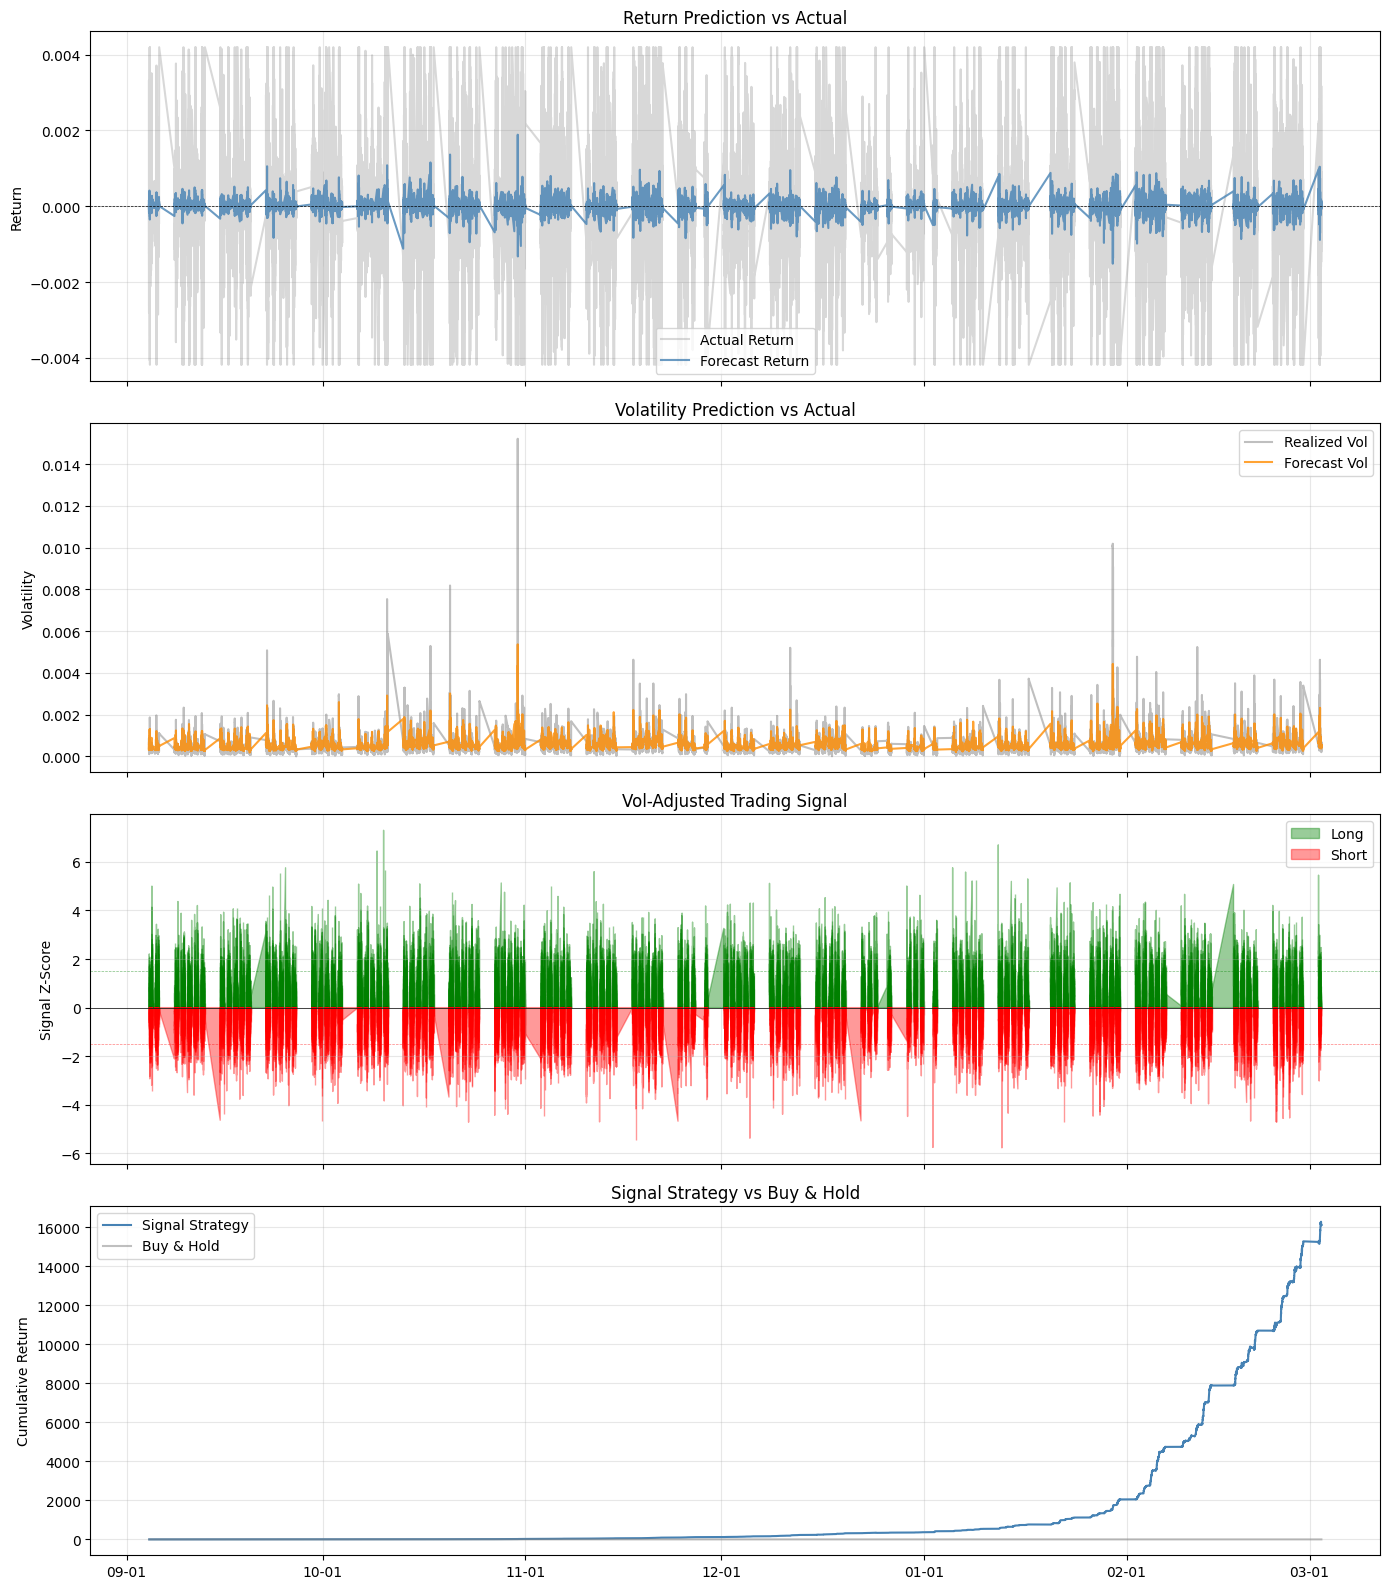

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# 1. Return forecast vs actual
ax = axes[0]
ax.plot(signals.index, signals["actual_return"], alpha=0.3, label="Actual Return", color="gray")
ax.plot(signals.index, signals["return_forecast"], alpha=0.8, label="Forecast Return", color="steelblue")
ax.set_ylabel("Return")
ax.set_title("Return Prediction vs Actual")
ax.legend()
ax.axhline(0, color="black", lw=0.5, ls="--")

# 2. Volatility forecast vs actual
ax = axes[1]
ax.plot(signals.index, signals["actual_vol"], alpha=0.5, label="Realized Vol", color="gray")
ax.plot(signals.index, signals["vol_forecast"], alpha=0.8, label="Forecast Vol", color="darkorange")
ax.set_ylabel("Volatility")
ax.set_title("Volatility Prediction vs Actual")
ax.legend()

# 3. Trading signal (z-scored)
ax = axes[2]
sz = signals["signal_z"].dropna()
ax.fill_between(sz.index, sz, 0, where=sz > 0, alpha=0.4, color="green", label="Long")
ax.fill_between(sz.index, sz, 0, where=sz < 0, alpha=0.4, color="red", label="Short")
ax.set_ylabel("Signal Z-Score")
ax.set_title("Vol-Adjusted Trading Signal")
ax.axhline(0, color="black", lw=0.5)
ax.axhline(1.5, color="green", lw=0.5, ls="--", alpha=0.5)
ax.axhline(-1.5, color="red", lw=0.5, ls="--", alpha=0.5)
ax.legend()

# 4. Cumulative return of signal (simple backtest proxy)
ax = axes[3]
valid = signals[["signal_z", "actual_return"]].dropna()
# Position = sign of signal, held for one period
position = valid["signal_z"].clip(-2, 2) / 2  # scale to [-1, 1]
strategy_ret = position.shift(1) * valid["actual_return"]  # no lookahead
cum_strategy = (1 + strategy_ret).cumprod()
cum_hold = (1 + valid["actual_return"]).cumprod()
ax.plot(cum_strategy.index, cum_strategy, label="Signal Strategy", color="steelblue")
ax.plot(cum_hold.index, cum_hold, label="Buy & Hold", color="gray", alpha=0.5)
ax.set_ylabel("Cumulative Return")
ax.set_title("Signal Strategy vs Buy & Hold")
ax.legend()

for a in axes:
    a.grid(True, alpha=0.3)
    a.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

plt.tight_layout()
plt.savefig("signal_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()